# Discovery limit for quasi-degenerate two axions

**Counting axions with IAXO** — B. Grinstein, C. Miró, P. Quílez (arXiv:2606.20826). Unbinned likelihood analysis.

- **H1:** Two axions with $m_1 \sim m_2 \sim 0$, parametrized by $\Delta m_{21}^2 = m_2^2 - m_1^2$
  $$P \propto \frac{1}{2} + \frac{1}{2} \cos\!\left(\frac{\Delta m_{21}^2\, L_{\mathrm{ES}}}{2\omega}\right) \times \text{damping}$$
- **H0:** Single massless axion ($P \propto 1$)

Scans over $\Delta m_{21}^2$ and computes the discrimination coupling $g_{a\gamma}^{\rm dis}(\sqrt{\Delta m_{21}^2})$
for energy resolutions $\omega_{\rm res} = 10,\,100,\,200$ eV.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

from iaxo_params import omega_min, omega_max, setup_plot_style
from conversion_prob import dN_domega
from test_statistic import compute_discovery_limit

## Parameters

In [4]:
E_res_keV = 0.1           # Energy resolution [keV]
n_uniform = 100000        # Grid points

# Dm2 scan range
delta_m2_min = (3e-9)**2  # eV^2
delta_m2_max = (2e-5)**2  # eV^2
n_dm2 = 100

delta_m2_vals = np.logspace(np.log10(delta_m2_min), np.log10(delta_m2_max), n_dm2)
sqrt_dm2 = np.sqrt(delta_m2_vals)

# Load CAST exclusion and IAXO projection
data = np.loadtxt('input_data/CAST_exclusion.dat')
sqrt_dm2_data = data[:, 0]  # sqrt(Delta_m21^2) [eV]
g_CAST = data[:, 1]         # g exclusion CAST [GeV^-1]
# g_IAXO = data[:, 2]         # g projection IAXO [GeV^-1]

#IAXO projection 
dataIAXO = np.loadtxt('input_data/IAXO_projection.dat')
sqrt_dm2_data = dataIAXO[:, 0]  # sqrt(Delta_m21^2) [eV]
g_IAXO = dataIAXO[:, 1]         # g projection IAXO [GeV^-1]

#IAXO+ projection 
dataIAXOp = np.loadtxt('input_data/IAXOplus_projection.dat')
sqrt_dm2_data = dataIAXOp[:, 0]  # sqrt(Delta_m21^2) [eV]
g_IAXOp = dataIAXOp[:, 1]         # g projection IAXO [GeV^-1]

# Interpolation of CAST exclusion limit (log-log)
from scipy.interpolate import interp1d
g_CAST_interp = interp1d(np.log10(sqrt_dm2_data), np.log10(g_CAST),
                         kind='linear', fill_value='extrapolate')

## Compute discovery limit
For a faster generation of the plot, load the previously generated discovery limit saved in the  results_data folder two cells below.

Runtime for n_dm2=100 is around 3 min.

In [3]:
print("Quasi-degenerate two axions vs single massless axion")
print(f"sqrt(Dm2) range: [{np.sqrt(delta_m2_min):.1e}, {np.sqrt(delta_m2_max):.1e}] eV")
print(f"n_points = {n_dm2}")

# H1 factory: given dm2 AND E_res, return spectrum function.
# Analytic damping inside P_conversion handles the fast oscillation smearing
# exactly; gaussian_filter1d in compute_q0 handles the smooth envelope.
def make_H1(dm2, E_res_keV_val):
    m2_eff = np.sqrt(dm2)
    return lambda E, m=m2_eff, er=E_res_keV_val: dN_domega(E, m1=0, m2=m, E_res_keV=er)

# H0: single massless axion
dN_H0 = lambda E: dN_domega(E, m1=0, m2=0)

g_discovery, q0_over_g4 = compute_discovery_limit(
    delta_m2_vals, lambda dm2: make_H1(dm2, E_res_keV), dN_H0,
    E_res_keV=E_res_keV, n_uniform=n_uniform, verbose=True)
g_discoveryEres10, q0_over_g4Eres10 = compute_discovery_limit(
    delta_m2_vals, lambda dm2: make_H1(dm2, 0.01), dN_H0,
    E_res_keV=0.01, n_uniform=n_uniform, verbose=True)
g_discoveryEres200, q0_over_g4Eres200 = compute_discovery_limit(
    delta_m2_vals, lambda dm2: make_H1(dm2, 0.2), dN_H0,
    E_res_keV=0.2, n_uniform=n_uniform, verbose=True)

Quasi-degenerate two axions vs single massless axion
sqrt(Dm2) range: [3.0e-09, 2.0e-05] eV
n_points = 100
  [1/100] mass = 9.00e-18
  [11/100] mass = 5.33e-17
  [21/100] mass = 3.16e-16
  [31/100] mass = 1.87e-15
  [41/100] mass = 1.11e-14
  [51/100] mass = 6.56e-14
  [61/100] mass = 3.88e-13
  [71/100] mass = 2.30e-12
  [81/100] mass = 1.36e-11
  [91/100] mass = 8.07e-11
  [1/100] mass = 9.00e-18
  [11/100] mass = 5.33e-17
  [21/100] mass = 3.16e-16
  [31/100] mass = 1.87e-15
  [41/100] mass = 1.11e-14
  [51/100] mass = 6.56e-14
  [61/100] mass = 3.88e-13
  [71/100] mass = 2.30e-12
  [81/100] mass = 1.36e-11
  [91/100] mass = 8.07e-11
  [1/100] mass = 9.00e-18
  [11/100] mass = 5.33e-17
  [21/100] mass = 3.16e-16
  [31/100] mass = 1.87e-15
  [41/100] mass = 1.11e-14
  [51/100] mass = 6.56e-14
  [61/100] mass = 3.88e-13
  [71/100] mass = 2.30e-12
  [81/100] mass = 1.36e-11
  [91/100] mass = 8.07e-11


In [4]:
# -- SAVE results to file --
_results_dir = 'results_data'
os.makedirs(_results_dir, exist_ok=True)

E_res_runs = {
    10:  (g_discoveryEres10,  q0_over_g4Eres10),
    100: (g_discovery,        q0_over_g4),
    200: (g_discoveryEres200, q0_over_g4Eres200),
}

for E_res_eV, (g_disc, q0) in E_res_runs.items():
    fname = os.path.join(_results_dir, f'Quasi_Eres{E_res_eV}eV.txt')
    data_out = np.column_stack([sqrt_dm2, g_disc, q0])
    header = ('Counting axions with IAXO (arXiv:2606.20826) by B. Grinstein, C. Miro and P. Quilez \\cite{Grinstein:2026alk}\n'
              'Quasi-degenerate g_discovery of 2 axions as a function of sqrt_dm2\n'
              'sqrt_dm2[eV]    g_disc[GeV^-1]    q0_over_g4[GeV^-4]')
    np.savetxt(fname, data_out, header=header, fmt='%.6e')
    print(f"Saved:  {fname}")

Saved:  results_data/Quasi_Eres10eV.txt
Saved:  results_data/Quasi_Eres100eV.txt
Saved:  results_data/Quasi_Eres200eV.txt


In [5]:
# -- LOAD results from file (run this INSTEAD of the computation cell above) --
_results_dir = 'results_data'

E_res_eV_list = [10, 100, 200]

loaded = {}
for E_res_eV in E_res_eV_list:
    fname = os.path.join(_results_dir, f'Quasi_Eres{E_res_eV}eV.txt')
    data = np.loadtxt(fname)   # columns: sqrt_dm2, g_disc, q0_over_g4
    loaded[E_res_eV] = {'sqrt_dm2': data[:, 0], 'g_disc': data[:, 1], 'q0': data[:, 2]}
    print(f'Loaded: {fname}')

sqrt_dm2            = loaded[100]['sqrt_dm2']
delta_m2_vals       = sqrt_dm2**2
g_discovery         = loaded[100]['g_disc']
q0_over_g4          = loaded[100]['q0']
g_discoveryEres10   = loaded[10]['g_disc']
q0_over_g4Eres10    = loaded[10]['q0']
g_discoveryEres200  = loaded[200]['g_disc']
q0_over_g4Eres200   = loaded[200]['q0']

Loaded: results_data/Quasi_Eres10eV.txt
Loaded: results_data/Quasi_Eres100eV.txt
Loaded: results_data/Quasi_Eres200eV.txt


## Plot

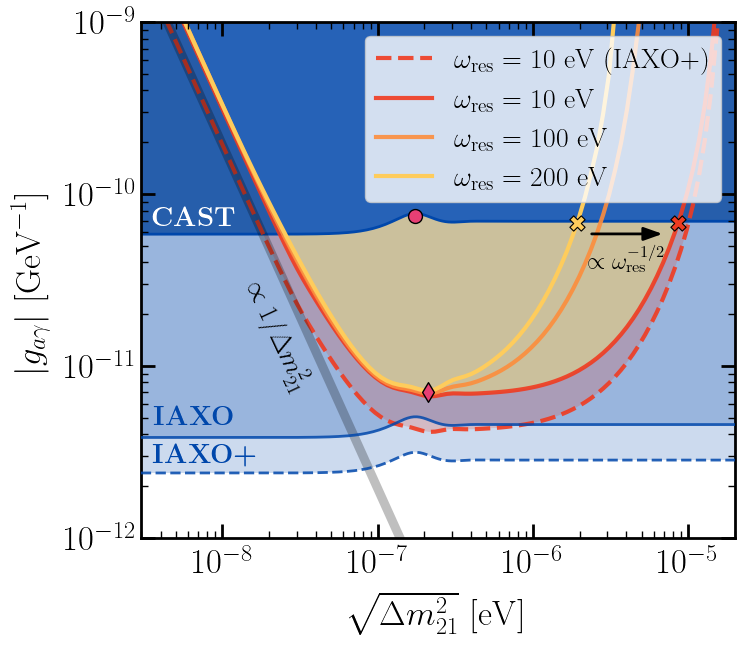

In [9]:
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import matplotlib.patheffects as pe

colorsBounds = ["#0047AB", "#0047AB", "#0047AB"]
colors = YlOrRd_5.mpl_colors[1:]
colorsMarkers = Bold_10.mpl_colors

def lighten(color, alpha):
    """Lighten a color as alpha would, but opaque."""
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(color))
    return tuple(alpha * c + (1 - alpha) * np.ones(3))

setup_plot_style()
fig, ax = plt.subplots(figsize=(8, 7))

# CAST exclusion
ax.loglog(sqrt_dm2_data, g_CAST, color=colorsBounds[2], lw=2, zorder=1)
ax.fill_between(sqrt_dm2_data, g_CAST, 1e-8, facecolor=colorsBounds[2], zorder=0.5, alpha=0.85)
ax.text(3.5e-9, 6.5e-11, r'{\bf CAST}', fontsize=20, color='w', zorder=1000)

# IAXO projection
ax.fill_between(sqrt_dm2_data, g_IAXO, g_CAST, facecolor=colorsBounds[1], zorder=0.05, alpha=0.4)
ax.loglog(sqrt_dm2_data, g_IAXO, colorsBounds[1], lw=2, ls='-', zorder=8, alpha=0.85)
ax.text(3.56e-9, 4.5e-12, r'{\bf IAXO}', fontsize=20, color=colorsBounds[1], zorder=1000)

# IAXO+ projection
ax.fill_between(sqrt_dm2_data, g_IAXOp, g_IAXO, facecolor=colorsBounds[0], zorder=0.05, alpha=0.2)
ax.loglog(sqrt_dm2_data, g_IAXOp, color=colorsBounds[0], lw=2, ls='--', zorder=8, alpha=0.85)
ax.text(3.5e-9, 2.7e-12, r'{\bf IAXO+}', fontsize=20, color=colorsBounds[0], zorder=1000)

# IAXO+ discrimination projection (dashed)
ax.loglog(sqrt_dm2, g_discoveryEres10*0.621, color=colors[2], lw=3, ls='--',
          label=r'$\omega_{\rm res} = 10\ \mathrm{eV}\ (\mathrm{IAXO+})$', zorder=2, alpha=0.9)
ax.fill_between(sqrt_dm2, g_discoveryEres10*0.621, g_discoveryEres10,
                facecolor=colors[2], alpha=0.2, zorder=0.1)

# Discrimination limits for 3 energy resolutions
ax.loglog(sqrt_dm2, g_discoveryEres10, color=colors[2], lw=3,
          label=r'$\omega_{\rm res} = 10\ \mathrm{eV}$', zorder=2, alpha=0.9)
ax.loglog(sqrt_dm2, g_discovery, color=colors[1], lw=3,
          label=r'$\omega_{\rm res} = 100\ \mathrm{eV}$', zorder=2, alpha=0.9)
ax.loglog(sqrt_dm2[:-6], g_discoveryEres200[:-6], color=colors[0], lw=3,
          label=r'$\omega_{\rm res} = 200\ \mathrm{eV}$', zorder=2, alpha=1)

# Fill two-axion discrimination region (10 eV) up to CAST
ax.fill_between(sqrt_dm2, g_discoveryEres10, 10**g_CAST_interp(np.log10(sqrt_dm2)),
                facecolor=colors[0], alpha=0.5, zorder=0.1)

# Reference line g ~ 1/Dm2^2
m_ref_start, m_ref_end = sqrt_dm2[0], sqrt_dm2[-1]
g_ref_start = g_discoveryEres10[0]
g_ref_end = g_ref_start * (m_ref_start / m_ref_end)**2
ax.loglog([m_ref_start, m_ref_end], [g_ref_start*0.621, g_ref_end*0.621], 'k-', lw=6.5, alpha=0.25)
ax.text(1.3e-8, 1.3e-11/1.8, r'$ \propto 1/\Delta m_{21}^{2}$', fontsize=20, color='k',
        zorder=1000, rotation=-65)

# Markers: worst IAXO projection point (circle), best discrimination point (diamond)
ax.scatter(1.75e-7, 7.47e-11, color=colorsMarkers[4], s=100, zorder=50, marker='o', edgecolor='black')
ax.scatter(2.12e-7, 7.04e-12, color=colorsMarkers[4], s=100, zorder=50, marker='d', edgecolor='black')

# CAST crossing markers & arrow for omega_res^{-1/2} scaling
# (crossing values from the scan in the last section of this notebook)
g_CAST_level = 6.7311e-11   # CAST bound [GeV^-1]
cross_200 = 1.91e-06        # sqrt(Dm2)_max for 200 eV
cross_10  = 8.538e-06       # sqrt(Dm2)_max for 10 eV
ax.scatter(cross_200, g_CAST_level, color=colors[0], s=120, zorder=55,
           marker='X', edgecolor='k', linewidths=0.8)
ax.scatter(cross_10, g_CAST_level, color=colors[2], s=120, zorder=55,
           marker='X', edgecolor='k', linewidths=0.8)
ax.annotate('', xy=(cross_10/1.2, g_CAST_level/1.15),
            xytext=(cross_200*1.2, g_CAST_level/1.15),
            arrowprops=dict(arrowstyle='-|>,head_length=0.45,head_width=0.16',
                            color='k', lw=2), zorder=60)
ax.text(np.sqrt(cross_200 * cross_10), g_CAST_level/1.95,
        r'$\propto \omega_{\rm res}^{-1/2}$', fontsize=17, ha='center',
        va='bottom', color='k', zorder=60)

ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$", labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$", labelpad=10)
ax.set_xlim([3e-9, 2e-5])
ax.set_ylim([1e-12, 1e-9])
ax.tick_params(axis='x', which='major', pad=8)
ax.tick_params(axis='x', which='minor', pad=8)

leg = ax.legend(fontsize=20, loc='upper right')
leg.set_zorder(20)
ax.set_zorder(100)
ax.set_axisbelow(False)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
fig.savefig('plots/Quasi-degenerate_disc.pdf', bbox_inches='tight')
fig.savefig('plots/Quasi-degenerate_disc.png', bbox_inches='tight')
plt.show()

# Optional: save directly into the Overleaf paper folder with the paper's figure names
save_overleaf = False
overleaf_dir = ('/home/pabloql/Cloud/Dropbox/Aplicaciones/Overleaf/'
                'Counting axions with helioscopes/plots')
if save_overleaf and os.path.isdir(overleaf_dir):
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(overleaf_dir, 'Quasi-degenerate_discovery.' + ext),
                    bbox_inches='tight')
    print('Saved to Overleaf: Quasi-degenerate_discovery.pdf/.png')